In [1]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import cv2
import numpy as np

train_path = 'Wildfire_Kaggle/train'
x_train = []
y_train = []
for direct in os.listdir(train_path):
    print("Loading Train".format(direct))
    for filename in os.listdir(os.path.join(train_path,direct)):
        img_path = os.path.join(train_path,direct,filename)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (77,77))
        img = np.array(img)
        img = img/255
        x_train.append(img)
        y_train.append(direct)

val_path = 'Wildfire_Kaggle/val'
x_val=[]
y_val=[]
for direct in os.listdir(val_path):
    print("Loading Val".format(direct))
    for filename in os.listdir(os.path.join(val_path,direct)):
        img_path = os.path.join(val_path,direct,filename)
        image = cv2.imread(img_path)
        image = cv2.resize(image,(77,77))
        image = np.array(image)
        image = image/255
        x_val.append(image)
        y_val.append(direct)

test_path = 'Wildfire_Kaggle/test'
x_test=[]
y_test=[]
for direct in os.listdir(test_path):
    print("Loading Test".format(direct))
    for filename in os.listdir(os.path.join(test_path,direct)):
        img_path = os.path.join(test_path,direct,filename)
        image = cv2.imread(img_path)
        image = cv2.resize(image,(77,77))
        image = np.array(image)
        image = image/255
        x_test.append(image)
        y_test.append(direct)

x_traindata = np.array(x_train)
x_valdata = np.array(x_val)
x_testdata = np.array(x_test)

Loading Train
Loading Train
Loading Val
Loading Val
Loading Test
Loading Test


Training set samples:


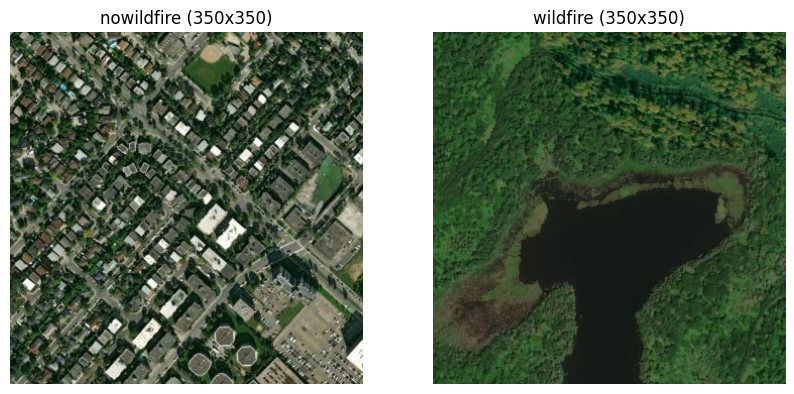

Validation set samples:


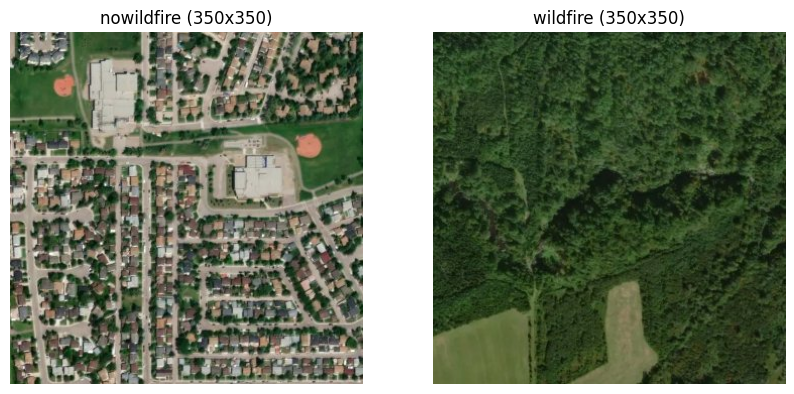

Test set samples:


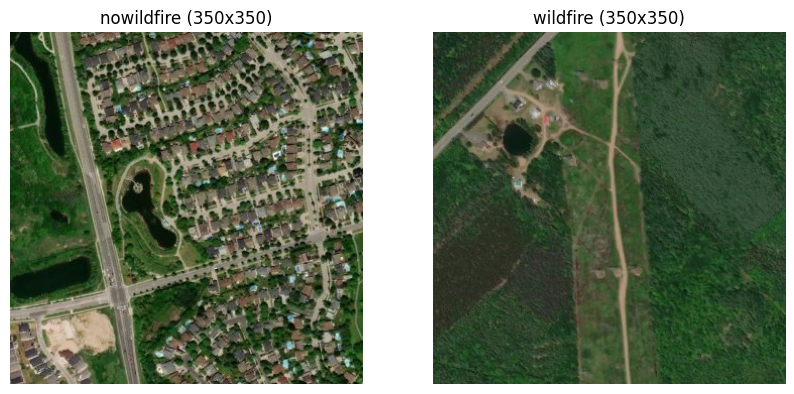

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import random
from tensorflow.keras.utils import load_img


def display_images(dataset):
    classes = os.listdir(dataset)  
    plt.figure(figsize=(10, 10))  

    for i, class_name in enumerate(classes):
        class_set = os.path.join(dataset, class_name)
        image_file = os.listdir(class_set)  
        random_image = random.choice(image_file)  
        img_path = os.path.join(class_set, random_image) 
        img = load_img(img_path)        
        plt.subplot(1, len(classes), i + 1) 
        plt.imshow(img)
        plt.axis('off')  
        plt.title(f"{class_name} ({img.size[0]}x{img.size[1]})") 

    plt.show()

print("Training set samples:")
display_images(train_path)

print("Validation set samples:")
display_images(val_path)

print("Test set samples:")
display_images(test_path)

In [4]:
x_train = np.array(x_train)
x_val = np.array(x_val)
x_test = np.array(x_test)

y_train = [1 if label == 'wildfire' else 0 for label in y_train]
y_val = [1 if label == 'wildfire' else 0 for label in y_val]
y_test = [1 if label == 'wildfire' else 0 for label in y_test]

y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

print("x_train shape:", x_train.shape)  
print("x_valid shape:", x_val.shape)
print("x_test shape:", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_valid shape:", y_val.shape)
print("y_test shape:", y_test.shape)

x_train shape: (30250, 77, 77, 3)
x_valid shape: (6300, 77, 77, 3)
x_test shape: (6300, 77, 77, 3)
y_train shape: (30250,)
y_valid shape: (6300,)
y_test shape: (6300,)


In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping  


model = Sequential([
    Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01), input_shape=(77, 77, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.01)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01))
])


model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stopping = EarlyStopping(
    monitor='val_loss',       
    patience=2,               
    restore_best_weights=True  
)


history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=5,                
    batch_size=64,
    callbacks=[early_stopping] 
)


test_loss, test_accuracy = model.evaluate(x_test, y_test)

print(f'Test Accuracy: {test_accuracy:.4f}')



Epoch 1/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 35s 72ms/step - accuracy: 0.8618 - loss: 0.6709 - val_accuracy: 0.9252 - val_loss: 0.3266
Epoch 2/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9107 - loss: 0.3472 - val_accuracy: 0.9129 - val_loss: 0.3196
Epoch 3/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9126 - loss: 0.3229 - val_accuracy: 0.9202 - val_loss: 0.3050
Epoch 4/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 70ms/step - accuracy: 0.9163 - loss: 0.3071 - val_accuracy: 0.9310 - val_loss: 0.2709
Epoch 5/5
473/473 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.9207 - loss: 0.2871 - val_accuracy: 0.9303 - val_loss: 0.2760
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9322 - loss: 0.2556
Test Accuracy: 0.9367


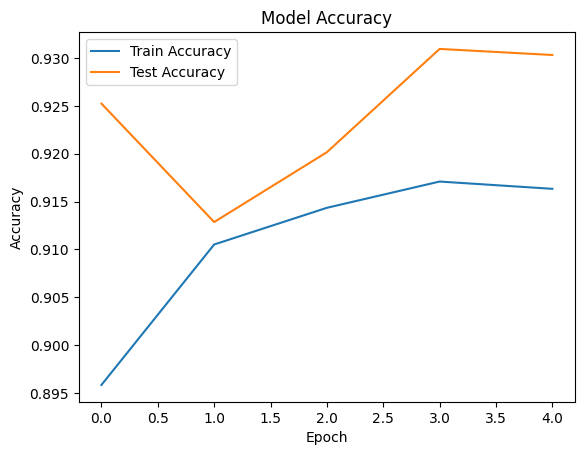

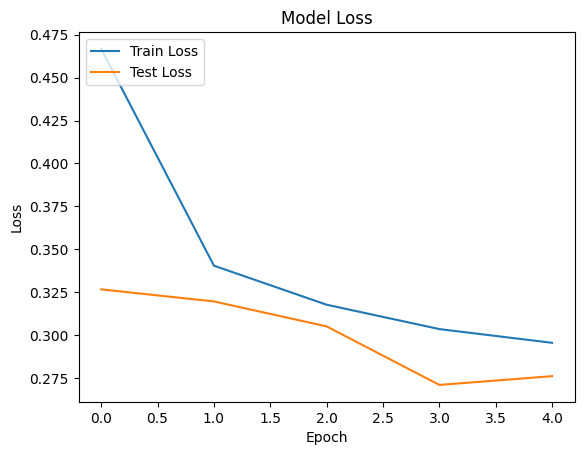

In [10]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

In [12]:
from sklearn.metrics import classification_report

y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)
y_test_pred = model.predict(x_test)

y_train_pred_classes = (y_train_pred > 0.5).astype("int32")
y_val_pred_classes = (y_val_pred > 0.5).astype("int32")
y_test_pred_classes = (y_test_pred > 0.5).astype("int32")

print(f"classification report for val : \n{classification_report(y_val, y_val_pred_classes)}")
print(f"classification report for test : \n{classification_report(y_test, y_test_pred_classes)}")

946/946 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
classification report for val : 
              precision    recall  f1-score   support

           0       0.94      0.90      0.92      2820
           1       0.92      0.95      0.94      3480

    accuracy                           0.93      6300
   macro avg       0.93      0.93      0.93      6300
weighted avg       0.93      0.93      0.93      6300

classification report for test : 
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      2820
           1       0.93      0.95      0.94      3480

    accuracy                           0.94      6300
   macro avg       0.94      0.93      0.94      6300
weighted avg       0.94      0.94      0.94      6300

